# Daily discount decisions for perishable food
**MAIB7002 · Group Q · Lisa's evaluation and pipeline extension**

Aashish Omprakash Pareek · Yuanyuan Yin · Lingyu Chen

We estimate next-day observed sales, decide when the evidence is sufficient to compare discounts,
and choose a supported discount subject to a sales-value constraint. The business user is a fresh-food
category manager. Better forecasts are measured; higher revenue or lower waste is not established.

This notebook extends Aashish's `pricing-ml-ap` commit `5b52099` without replacing his notebook or helper modules.
The Chinese guides in `docs/` explain both versions line by line. This English notebook is the presentation and runnable demonstration.

**Reading order:** business question → data and decision timing → models → matched evaluation → errors → decision rules → real case → limitations.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    raise RuntimeError("Open this notebook from the repository root")
sys.path.insert(0, str(ROOT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from finalproject_pricingml import config as C, v2
OUT = ROOT / "results" / "v2"
pd.set_option("display.precision", 5)
%matplotlib inline

# False: verify saved artifacts and run a small live model demonstration offline.
# True: rebuild features and rerun all 66 model fits; requires the two verified raw files.
RERUN_FULL_EXPERIMENT = False
if RERUN_FULL_EXPERIMENT:
    v2.run(OUT)
verification = v2.verify_saved(OUT)
display(verification)

{'status': 'passed',
 'models_checked': 17,
 'oof_rows': 10920,
 'test_rows': 2184,
 'recommendation_rows': 2184,
 'raw_sha256': {'train': '6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d',
  'eval': '1b118840664280c6b88bffc84c80ee1f54c05d911e354b7599e5da10995e960e'},
 'checked_utc': '2026-10-09T17:54:31.458792+00:00',
 'retrained_here': False}

## 1. Business decision and evidence

The manager first asks **whether a discount can be responsibly recommended**, then **how deep it should be**.
Sales history, previous-day stockout hours and activity, tomorrow's calendar, and the proposed daily discount
are available inputs. Tomorrow's realized sales, weather and stockouts are not predictors.

Success for the forecasting component means lower **mean absolute error (MAE)** than the 7-day mean baseline on the same rows.
The decision component is assessed for historical support, complete output coverage, transparent reasons and constraint compliance.
Its predicted gains are scenarios, not an observed policy return.

The dataset has no inventory ages, batch-level expiry dates or unit prices. A week without a stockout does not mean that stock is a week old.

## 2. Public data and unit of observation

Source: [Dingdong FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K), CC BY 4.0.
One row is one store-product-day. `sale_amount` is normalized observed sales; **an MAE of 0.28 does not mean 0.28 loaves or dollars**.
Stockouts censor observed sales: customers' unmet demand is not recorded as sales.

We use the teammate's 312 store-product series in five stores in city 0, selected for discount variation from the original 90-day training period.
This retrospective cohort makes comparison possible but creates selection optimism within the validation period and limits generalization.
Public raw files are verified against fixed SHA-256 values. The small derived feature table and saved predictions are included for offline inspection.

In [2]:
feat = pd.read_parquet(OUT / "features.parquet")
plan = json.loads((OUT / "experiment_plan.json").read_text())
selection = json.loads((OUT / "selection.json").read_text())
comparison = pd.read_csv(OUT / "comparison.csv")
oof = pd.read_csv(OUT / "validation_predictions.csv", parse_dates=["dt"])
test_predictions = pd.read_csv(OUT / "test_predictions.csv", parse_dates=["dt"])
print("Series:", len(feat[C.KEY].drop_duplicates()), "Stores:", feat.store_id.nunique())
display(feat.groupby(["split", "val_fold"]).agg(rows=("dt", "size"), first=("dt", "min"), last=("dt", "max")))
display(pd.DataFrame(plan["environment"].items(), columns=["package", "version"]))

Series: 312 Stores: 5


rows      first       last
split val_fold                             
test  0          2184 2024-06-26 2024-07-02
train 0         14976 2024-04-04 2024-05-21
      1          2184 2024-05-22 2024-05-28
      2          2184 2024-05-29 2024-06-04
      3          2184 2024-06-05 2024-06-11
      4          2184 2024-06-12 2024-06-18
      5          2184 2024-06-19 2024-06-25

,package,version
0,python,3.12.13
1,numpy,2.5.3
2,pandas,3.0.6
3,scikit-learn,1.9.1
4,catboost,1.2.10
5,pyarrow,25.0.1


## 3. Feature timing and a real input row

The date in a row is the **target day**, called day t+1. `sales_t` is yesterday's observed sales;
`sales_lag7` is sales seven days before the target date. Rolling windows are shifted **before** aggregation.
For example, `shift(1).rolling(7).mean()` excludes the target day's sales.

The 10 base inputs match the teammate implementation. In particular, `activity_t` is **yesterday's** activity flag;
the older main branch used the target day's planned activity. Identical baseline scores do not establish identical feature sets.

The history extension adds sales at lags 2 and 3, means over 3 and 14 days, 7-day variability,
the difference between the 3-day and 7-day means, mean previous discount and recent stockout-day count.
It also passes store and product IDs to CatBoost as **categories**, not numeric magnitudes.
There are 18 numeric inputs and two categorical inputs. All models keep exactly the same benchmark rows.

In [3]:
example = feat[feat.split == "test"].sort_values(C.ROW_KEY).iloc[[0]]
display(example[C.ROW_KEY + C.FEATURES + v2.EXTRA + v2.IDS + [C.TARGET]].T.rename(columns={example.index[0]: "real case"}))
feature_dictionary = pd.DataFrame({
    "group": ["Base"]*len(C.FEATURES) + ["Additional history"]*len(v2.EXTRA) + ["Categorical ID"]*len(v2.IDS),
    "feature": C.FEATURES + v2.EXTRA + v2.IDS})
display(feature_dictionary)

,real case
store_id,18
product_id,11
dt,2024-06-26 00:00:00
sales_t,1.4
sales_lag7,2.0
sales_mean7,1.25714
sales_mean_to_date,1.17556
stockout_hours_t,0.0
discount_t,0.997
discount_next,0.989


,group,feature
0,Base,sales_t
1,Base,sales_lag7
2,Base,sales_mean7
3,Base,sales_mean_to_date
4,Base,stockout_hours_t
5,Base,discount_t
6,Base,discount_next
7,Base,activity_t
8,Base,holiday_next
9,Base,weekday_next


## 4. What each method learns

| Method | Inputs and learning | Main technical choice |
|---|---|---|
| 7-day mean baseline | Average the previous seven observed sales | No fitted model |
| Same-weekday baseline | Reuse sales from seven days earlier | No fitted model |
| Ridge | A linear combination of standardized inputs with a squared-coefficient penalty | alpha = 10 |
| Decision tree | Recursive feature splits reduce squared error; predict a leaf mean | Depth 6; at least 20 rows per leaf |
| Random Forest (RF) | Average 300 bootstrap-trained trees | Depth 10; leaf size 3; half the features per split |
| HistGradientBoosting | Add trees that correct the current model's errors | 300 iterations; 15 leaves; learning rate 0.05 |
| CatBoost | Sequential symmetric trees, with categorical target statistics for ID-enabled variants | Depth 5; 500 iterations; learning rate 0.03 |
| kNN reference | Average the 25 nearest standardized training rows | Scaling fitted inside each training fold |

For boosting, $F_m(x)=F_{m-1}(x)+\eta h_m(x)$: $x$ is the input row, $F_m$ the prediction after step $m$,
$h_m$ the new tree, and $\eta$ the learning rate. The new tree approximates the direction that reduces the training loss.
With squared loss the residual magnitude matters strongly; MAE is less sensitive to individual large errors and targets a conditional median.
Consequently a MAE-trained forecast is not automatically an expected demand or expected revenue estimate.

For a blend, $\hat y=w\hat y_{RF}+(1-w)\hat y_{CB}$: $\hat y$ is predicted normalized sales and $w$ the RF weight.
The components can make different errors, so averaging can help; their errors are strongly correlated, so gains are limited.

## 5. Recorded experiment and chronological evaluation

Eleven standalone designs and four blends were declared in code before this run's final-period scoring; two baselines are reported first.
The five validation weeks begin on May 22, May 29, June 5, June 12 and June 19, 2024.
Each fit uses only dates before its validation week. We average weekly MAE and choose the smallest value.
The final-period dates are June 26–July 2. Forecasts are **rolling one day ahead**: actual earlier days update the lags within a week,
while the model itself is fitted only at the beginning of that week. This is not a seven-day-ahead forecast.

**Development history matters:** the final week and validation folds have already been used by earlier versions.
This extension is exploratory and its final-period results are a shared benchmark, not a new untouched holdout.
The new selection is saved before final scoring to prevent additional within-run test-based changes; this does not erase past exposure.

The controlled technical experiment compares **RMSE versus MAE training loss with identical extended features, depth, iterations, learning rate and regularization**.
We expected MAE training to help the primary absolute-error metric, potentially at the expense of large-error sensitivity.
The extended feature package is also compared with the base package, but several features change together, so that contrast does not identify an individual feature's causal contribution.

In [4]:
display(pd.DataFrame(plan["candidates"]).fillna("-"))
print("Selection:", selection["selected_model"])
print("Best standalone:", selection["best_standalone"])
print("Locked before this run's final scoring:", selection["selected_before_test_scoring_utc"])
display(comparison[comparison.model.isin(["CatBoost history + IDs", "CatBoost history + IDs MAE"])][
    ["model", "validation_mae", "test_mae", "test_rmse"]])

,name,kind,features,alpha,depth,leaf,monotonic,iterations,lr,loss,l2
0,Ridge,ridge,base,10.0,-,-,-,-,-,-,-
1,Decision tree,tree,base,-,6.0,20.0,-,-,-,-,-
2,HistGradientBoosting,hist,base,-,-,-,False,-,-,-,-
3,kNN reference,knn,base,-,-,-,-,-,-,-,-
4,Teammate RF,rf,base,-,-,-,-,-,-,-,-
5,Teammate CatBoost,cat,base,-,5.0,-,-,500.0,0.03,RMSE,3.0
6,Main CatBoost,cat,base,-,4.0,-,-,400.0,0.05,RMSE,5.0
7,CatBoost MAE,cat,base,-,5.0,-,-,500.0,0.03,MAE,3.0
8,CatBoost history + IDs,cat,history_ids,-,5.0,-,-,500.0,0.03,RMSE,5.0
9,CatBoost history + IDs MAE,cat,history_ids,-,5.0,-,-,500.0,0.03,MAE,5.0


Selection: RF + validation best (25/75)
Best standalone: CatBoost history + IDs MAE
Locked before this run's final scoring: 2026-10-09T17:48:26.124294+00:00


,model,validation_mae,test_mae,test_rmse
10,CatBoost history + IDs,0.29715,0.28423,0.45500
11,CatBoost history + IDs MAE,0.29449,0.28458,0.46006


## 6. Results

For $n$ observed rows, actual sales $y_i$ and predictions $\hat y_i$:

$$MAE=\frac{1}{n}\sum_i|y_i-\hat y_i|,\qquad RMSE=\sqrt{\frac{1}{n}\sum_i(y_i-\hat y_i)^2}.$$

WAPE is $\sum_i|y_i-\hat y_i|/\sum_i|y_i|$. Lower is better for all three.
Validation MAE chooses the model. RMSE diagnoses large misses and WAPE provides relative scale.
We do not switch the winner just because another design has a lower final-period RMSE.

,model,validation_mae,test_mae,test_rmse,test_wape,selected
0,7-day mean,0.32840,0.31418,0.52089,0.32436,False
1,Same weekday,0.41502,0.39975,0.61707,0.41270,False
2,Ridge,0.31553,0.30725,0.50280,0.31720,False
3,Decision tree,0.32359,0.32222,0.49868,0.33266,False
4,HistGradientBoosting,0.30585,0.29006,0.45692,0.29945,False
5,kNN reference,0.31198,0.30398,0.49002,0.31383,False
6,Teammate RF,0.30244,0.29235,0.46459,0.30182,False
7,Teammate CatBoost,0.30330,0.28965,0.46026,0.29903,False
8,Main CatBoost,0.30355,0.28754,0.45110,0.29685,False
9,CatBoost MAE,0.30273,0.28844,0.46459,0.29778,False


Final-period MAE reduction versus 7-day mean: 9.80%
Final-period MAE reduction versus Teammate blend 50/50: 2.02%


model,RF + validation best (25/75),Teammate blend 50/50
fold,,
1,0.28155,0.28759
2,0.28126,0.29022
3,0.32512,0.33419
4,0.27917,0.29023
5,0.30299,0.30404


Weeks better than teammate: 5 of 5


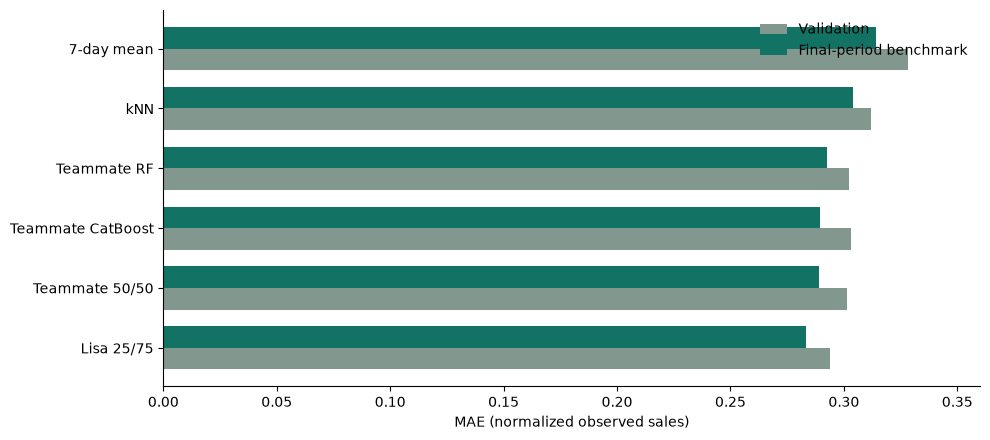

In [5]:
display(comparison[["model", "validation_mae", "test_mae", "test_rmse", "test_wape", "selected"]])
winner = selection["selected_model"]
metrics = comparison.set_index("model")
for ref in ["7-day mean", "Teammate blend 50/50"]:
    gain = 100 * (metrics.loc[ref, "test_mae"] - metrics.loc[winner, "test_mae"]) / metrics.loc[ref, "test_mae"]
    print(f"Final-period MAE reduction versus {ref}: {gain:.2f}%")
folds = pd.read_csv(OUT / "validation_folds.csv")
paired = folds[folds.model.isin(["Teammate blend 50/50", winner])].pivot(index="fold", columns="model", values="mae")
display(paired)
print("Weeks better than teammate:", int((paired[winner] < paired["Teammate blend 50/50"]).sum()), "of 5")

show = ["7-day mean", "kNN reference", "Teammate RF", "Teammate CatBoost", "Teammate blend 50/50", winner]
fig, ax = plt.subplots(figsize=(10, 4.5))
pos = np.arange(len(show)); width = .36
ax.barh(pos+width/2, metrics.loc[show, "validation_mae"], width, label="Validation", color="#82988f")
ax.barh(pos-width/2, metrics.loc[show, "test_mae"], width, label="Final-period benchmark", color="#127263")
ax.set_yticks(pos, ["7-day mean", "kNN", "Teammate RF", "Teammate CatBoost", "Teammate 50/50", "Lisa 25/75"])
ax.invert_yaxis(); ax.set_xlim(0, .36); ax.set_xlabel("MAE (normalized observed sales)")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(OUT / "model_comparison.png", dpi=180); plt.show()

## 7. Errors and practical limits

Inspect all discount bands, all stores and all days, rather than selecting only favorable cases.
The largest errors below are selected mechanically by absolute error.
Target-day stockout status is used **only to diagnose errors after the fact**, never as a model input.

The paired interval resamples entire store-product series, keeping their seven days together.
It is descriptive: five stores and one week are too little to establish broad reliability, and shared-store shocks and selection optimism are not corrected.

In [6]:
slices = pd.read_csv(OUT / "error_slices.csv")
display(slices[slices["slice"] == "discount"])
display(slices[(slices["slice"] == "store") & (slices.model == winner)])
display(pd.read_csv(OUT / "largest_errors.csv").head(5))
display(json.loads((OUT / "paired_comparison.json").read_text()))

,slice,value,model,mae,rmse,wape,n
36,discount,none_or_small,7-day mean,0.27105,0.39351,0.33457,1186
37,discount,none_or_small,Teammate blend 50/50,0.23298,0.32635,0.28758,1186
38,discount,none_or_small,RF + validation best (25/75),0.22907,0.32248,0.28275,1186
39,discount,moderate,7-day mean,0.30332,0.44538,0.30416,757
40,discount,moderate,Teammate blend 50/50,0.29821,0.43218,0.29905,757
41,discount,moderate,RF + validation best (25/75),0.29278,0.43624,0.29360,757
42,discount,deep,7-day mean,0.56059,1.03619,0.33796,241
43,discount,deep,Teammate blend 50/50,0.53784,0.89476,0.32424,241
44,discount,deep,RF + validation best (25/75),0.52122,0.88049,0.31423,241


,slice,value,model,mae,rmse,wape,n
23,store,18,RF + validation best (25/75),0.28720,0.45645,0.27926,448
26,store,154,RF + validation best (25/75),0.24521,0.35712,0.33750,420
29,store,182,RF + validation best (25/75),0.29080,0.46107,0.29717,427
32,store,235,RF + validation best (25/75),0.26912,0.38771,0.26895,441
35,store,343,RF + validation best (25/75),0.32235,0.57915,0.29444,448


,store_id,product_id,dt,target_sales,discount_next,target_stockout_hours,7-day mean,Same weekday,Ridge,Decision tree,...,Main CatBoost,CatBoost MAE,CatBoost history + IDs,CatBoost history + IDs MAE,Monotonic HistGBR,Teammate blend 50/50,RF + validation best (25/75),RF + validation best (50/50),RF + validation best (75/25),selected_abs_error
0,343,38,2024-06-29,10.3,0.505,9,1.37143,6.0,2.80238,4.70000,...,5.71405,4.85541,5.53911,4.65188,5.97617,5.35482,4.73391,4.81595,4.89798,5.56609
1,343,122,2024-06-30,10.6,0.633,0,6.84286,6.2,6.59363,6.59524,...,6.43388,6.08256,6.76526,6.57444,6.77774,6.28268,6.48249,6.39055,6.29860,4.11751
2,18,122,2024-06-30,10.1,0.633,0,5.92857,6.9,5.78047,6.59524,...,6.62666,6.19692,6.08406,6.05533,6.77774,6.29719,6.11697,6.17862,6.24026,3.98303
3,182,122,2024-06-30,9.1,0.919,0,5.77143,8.7,5.50543,6.59524,...,6.42963,5.98247,5.29021,4.92063,5.55321,6.02179,5.11993,5.31924,5.51854,3.98007
4,343,122,2024-07-02,10.0,0.558,4,7.32857,8.2,6.55483,5.63913,...,5.77410,6.11545,5.69424,6.46938,6.28005,5.76323,6.33889,6.20841,6.07792,3.66111


{'selected_minus_teammate_mae': -0.005842771261994179,
 'series_bootstrap_95pct_interval': [-0.010104686129866775,
  -0.0011266001930648228],
 'limitation': 'Descriptive 7-day, 5-store interval; shared-store correlation and selection optimism not corrected.'}

## 8. A live, traceable model example

For the first store-product-day in the final period, refit only the selected blend members on the original training rows.
No parameter is changed. Compare the reproduced prediction to the saved result.
The member predictions, blend arithmetic and RF tree path expose how the final number is constructed.
This can run using the included small feature table without downloading the full raw dataset.

In [7]:
training = feat[feat.split == "train"]
specs = {s["name"]: s for s in plan["candidates"]}
members = selection["blend_weights"].get(winner, {winner: 1.})
live_models = {}
example_values = []
from threadpoolctl import threadpool_limits
for name, weight in members.items():
    spec = specs[name]
    with threadpool_limits(limits=4):
        model = v2.estimator(spec).fit(training[v2.columns(spec)], training[C.TARGET])
    live_models[name] = model
    prediction = float(v2.predict(model, example, spec)[0])
    example_values.append({"member": name, "weight": weight, "prediction": prediction, "weighted_part": weight*prediction})
example_table = pd.DataFrame(example_values)
display(example_table)
live_prediction = example_table.weighted_part.sum()
case_key = example.iloc[0]
saved_case = test_predictions[(test_predictions.store_id == case_key.store_id) &
    (test_predictions.product_id == case_key.product_id) & (test_predictions.dt == case_key["dt"])].iloc[0]
print(f"Blend = {live_prediction:.6f}; actual observed sales = {case_key[C.TARGET]:.6f}")
print("Maximum replay difference:", abs(live_prediction - saved_case[winner]))
assert np.isclose(live_prediction, saved_case[winner], atol=1e-6)

forest = live_models.get("Teammate RF")
if forest is not None:
    x = example[C.FEATURES].to_numpy()
    tree = forest.estimators_[0]
    leaf = tree.apply(x)[0]
    print("First RF tree leaf prediction:", float(tree.tree_.value[leaf, 0, 0]))
    print("RF prediction = mean of", len(forest.estimators_), "tree predictions:",
          float(np.mean([t.predict(x)[0] for t in forest.estimators_])))
    path = tree.decision_path(x).indices
    for node in path:
        feature = tree.tree_.feature[node]
        if feature >= 0:
            value, threshold = x[0, feature], tree.tree_.threshold[node]
            print(f"{C.FEATURES[feature]} = {value:.4f} {'<=' if value <= threshold else '>'} {threshold:.4f}")

,member,weight,prediction,weighted_part
0,Teammate RF,0.25,1.24649,0.31162
1,CatBoost history + IDs MAE,0.75,1.20780,0.90585


Blend = 1.217470; actual observed sales = 0.600000
Maximum replay difference: 0.0
First RF tree leaf prediction: 1.1382456140350878
RF prediction = mean of 300 tree predictions: 1.2464884870414898
sales_mean7 = 1.2571 <= 1.7500
sales_mean7 = 1.2571 > 0.8493
discount_next = 0.9890 > 0.5550
discount_next = 0.9890 <= 0.9990
sales_mean7 = 1.2571 > 1.1364
weekday_next = 2.0000 <= 4.5000
discount_next = 0.9890 > 0.7230
sales_lag7 = 2.0000 > 1.7500
sales_mean7 = 1.2571 <= 1.5643
sales_mean_to_date = 1.1756 <= 1.1924


## 9. Whether to discount, then how much

1. **Check recent supply evidence.** A stockout yesterday triggers supply review because sales may be censored. It does not prove all stock was sold or that tomorrow's stock is fresh.
2. **Check historical support.** Each candidate needs at least three training days within ±0.025 for this store-product. A supported full-price reference is also required.
3. **Compare scenarios.** Hold known context fixed, vary only the candidate rate $d$, and compute forecast $\hat y(d)$.
4. **Require agreement.** The selected model, RF and reference CatBoost must each predict at least 5% more sales while keeping $d\hat y(d)$ at least 95% of their own full-price value.
5. **Choose depth.** Maximize the selected forecast within those candidates; use the highest rate (mildest discount) within 1% of the best sales prediction.

Here $d=0.9$ means **10% off**, not 90% off. $d\hat y(d)$ is a relative sales-value proxy; it is neither currency nor profit.
The thresholds are explicit illustrative choices, not learned optimal business rules. Cross-model agreement is a sensitivity check, not a confidence interval.

Each input produces one output: a discount, keep full price, or a named review/abstention reason.
We never infer inventory age from a stockout count. Candidate support reduces extrapolation but does not remove confounding.

In [8]:
policy = json.loads((OUT / "policy_summary.json").read_text())
recs = pd.read_csv(OUT / "recommendations.csv", parse_dates=["dt"])
responses = pd.read_csv(OUT / "discount_response.csv", parse_dates=["dt"])
display(pd.DataFrame(policy["status_counts"].items(), columns=["status", "rows"]))
print(f"Explicit output coverage: {policy['output_rows']}/{policy['rows']}")
print(f"Actionable recommendation coverage: {policy['decision_coverage']:.1%}")
print(f"Manual review / abstention: {policy['manual_review_or_abstain_share']:.1%}")
print("These are decision diagnostics, not realized policy rewards.")

,status,rows
0,recommend_discount,1179
1,review_stockout,967
2,review_model_disagreement,38


Explicit output coverage: 2184/2184
Actionable recommendation coverage: 54.0%
Manual review / abstention: 46.0%
These are decision diagnostics, not realized policy rewards.


## 10. A real discount scenario and a failure case

Use the first supported recommendation in key order, not the most impressive predicted gain.
Only the recorded discount has an observed sales outcome; alternative-price outcomes are unknown.
Then inspect the first supply-review case to demonstrate when the system declines to decide.

,recommendation
store_id,18
product_id,11
dt,2024-06-26 00:00:00
status,recommend_discount
recommended_rate,0.9
predicted_sales,1.29123
predicted_gain,0.2026
value_share,1.08234
reason,Supported candidate passes model agreement and...


,rate,support_days,supported,selected_sales,rf_sales,cat_sales,selected_value_proxy
0,1.00,33,True,1.07370,1.15812,1.08379,1.07370
2184,0.95,10,True,1.24016,1.25511,1.26773,1.17815
4368,0.90,12,True,1.29123,1.26637,1.30655,1.16211
6552,0.85,23,True,1.38568,1.28888,1.40019,1.17783
8736,0.80,5,True,1.43157,1.35600,1.48510,1.14526
10920,0.75,0,False,1.47889,1.38529,1.60322,1.10916
13104,0.70,0,False,1.71976,1.49325,1.91796,1.20383
15288,0.60,0,False,1.92641,1.56242,2.42364,1.15585


,store_id,product_id,dt,sales_t,sales_mean7,stockout_hours_t,discount_next,target_sales
83,18,11,2024-06-26,1.4,1.25714,0.0,0.989,0.6


,store_id,product_id,dt,status,recommended_rate,predicted_sales,predicted_gain,value_share,reason
2,18,11,2024-06-28,review_stockout,NaN,NaN,NaN,NaN,Recent censored sales; verify tomorrow's suppl...


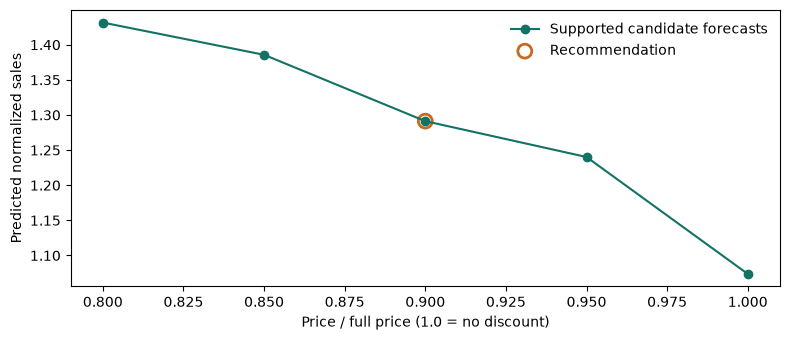

In [9]:
case = recs[recs.status == "recommend_discount"].sort_values(C.ROW_KEY).iloc[0]
mask = ((responses.store_id == case.store_id) & (responses.product_id == case.product_id) & (responses.dt == case["dt"]))
case_curve = responses.loc[mask].sort_values("rate", ascending=False).copy()
case_curve["selected_value_proxy"] = case_curve.rate * case_curve.selected_sales
display(case.to_frame("recommendation"))
display(case_curve[["rate", "support_days", "supported", "selected_sales", "rf_sales", "cat_sales", "selected_value_proxy"]])
actual_case = feat[(feat.store_id == case.store_id) & (feat.product_id == case.product_id) & (feat.dt == case["dt"])]
display(actual_case[C.ROW_KEY + ["sales_t", "sales_mean7", "stockout_hours_t", "discount_next", C.TARGET]])
display(recs[recs.status == "review_stockout"].sort_values(C.ROW_KEY).head(1))

fig, ax = plt.subplots(figsize=(8, 3.5))
supported = case_curve[case_curve.supported]
ax.plot(supported.rate, supported.selected_sales, "o-", color="#127263", label="Supported candidate forecasts")
ax.scatter([case.recommended_rate], [case.predicted_sales], s=100, facecolors="none", edgecolors="#c76a20", linewidths=2, label="Recommendation")
ax.set_xlabel("Price / full price (1.0 = no discount)"); ax.set_ylabel("Predicted normalized sales")
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(OUT / "worked_scenario.png", dpi=180); plt.show()

## 11. Transfer stress test after model selection

After locking the winner, a separate check chose 100 eligible series outside city 0 using a fixed SHA-256 ordering of store-product keys from training data only.
The three required estimators were fitted on the original 312 series, with no fitting on the new series and no retuning.
The resulting 700 evaluation rows span 93 new stores in 16 other cities, including 47 product IDs not seen by the fitted models.
Earlier observed days of each new series still supply the lag features, as required for rolling daily prediction.

The new blend does **not** outperform the teammate blend here, and its RMSE is worse than even the 7-day mean.
Thus the measured improvement applies to the original cohort; it does not establish general transfer to new stores.
We retain the original validation selection and report this failure instead of changing the winner after seeing these outcomes.
This is a locked transfer stress test, not a claim that no group member ever saw these public data before.

In [10]:
transfer_dir = ROOT / "results" / "v2_transfer"
display(pd.read_csv(transfer_dir / "summary.csv"))
display(json.loads((transfer_dir / "run_receipt.json").read_text()))

,model,mae,rmse,wape,rows
0,7-day mean,0.29667,0.48356,0.36332,700
1,Same weekday,0.36263,0.57550,0.44410,700
2,Teammate blend 50/50,0.28842,0.47096,0.35322,700
3,RF + validation best (25/75),0.28902,0.48863,0.35395,700


{'status': 'passed',
 'completed_utc': '2026-10-09T17:49:34.148769+00:00',
 'duration_seconds': 11.66890704099933,
 'plan_sha256': 'e061c4f5a5f4513181a5f1e9d30cf2239611f0df320e30c3016d53fb254f513b',
 'prediction_sha256': '9cbaffd07ff2025a7453a584c9a43a3d7575084afaf9a854872077450daa1ca2',
 'fitted_estimators': 3,
 'training_rows': 25896,
 'selected_series': 100,
 'evaluation_series': 100,
 'evaluation_rows': 700,
 'maximum_expected_rows': 700,
 'excluded_feature_rows': 0,
 'new_cities': 16,
 'new_stores': 93,
 'unseen_product_ids': 47,
 'winner_changed': False,
 'tuning_performed': False,
 'interpretation': 'Transfer stress check with train-only deterministic cohort selection. Sales forecasting only; no policy or causal uplift evaluation.'}

## 12. What improved, and what remains unproved

The extension provides a reproducible matched comparison, a real worked example, richer past-only features,
an objective aligned with MAE, keyed blend alignment and a complete decision output with abstention.
The teammate's original code and saved results remain available and are credited.

The strongest unresolved issues are observational discount confounding, stockout censoring, limited geography and repeated use of evaluation periods.
Most eligible cases still receive a discount; review rules do not demonstrate that these discounts are beneficial.
MAE forecasts target a median, so multiplying them by price cannot be called expected-revenue maximization.
Stock quantity, replenishment, expiry and cost data are required to assess actual inventory, profit or waste outcomes.
A prospective pilot or defensible causal evaluation is needed before operational use.

No reinforcement-learning model is used. The available data do not provide a verified sequential inventory environment or reliable off-policy policy-value estimate.

## 13. Reproduce and demonstrate

From a clean repository copy:
```bash
docker compose up --build -d
docker compose exec lab python scripts/jupyter_v2_url.py
docker compose exec lab python scripts/run_v2.py --verify-only
docker compose exec lab python -m unittest discover -s tests -v
```

The saved-results demonstration and live worked example run offline. To reproduce all data preparation and 66 fits:
```bash
docker compose exec lab python scripts/download_public_data.py
docker compose exec lab python scripts/run_v2.py
docker compose exec lab python scripts/execute_lisa_notebook.py
```

See `docs/assignment_requirements.md` for the brief, the Chinese walkthroughs for study, and `docs/CONTRIBUTIONS_TEMPLATE.md` for mandatory personal declarations.
This notebook and the poster are prepared materials; the authors must verify their contributions and submit through Moodle themselves.